# DATA 620 Project 1

In [35]:
from pathlib import Path


# Walk up from cwd until we find the project1 directory
def find_project_dir(name="project1/processed") -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidate = parent / name
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{name}' directory")


PROJECT_DIR = find_project_dir()

## Introduction

For our project, we've taken a Spotify dataset made available on [Kaggle.com by Maharshi Pandya](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) and used it to create a network of music.

- We first preprocessed the data by splitting multi-artist tracks and mapping granular Spotify genres into broader genre categories. 
- While the original data can be represented as a mixed artist–track–genre network, our centrality analysis is performed on an artist-only collaboration network, where two artists are connected if they appear on the same track.
- Each artist node includes a categorical attribute representing its primary genre.

We will now use this data to perform network analysis to better understand **Degree Centrality** and **Eigenvector Centrality** 

In [36]:
import pandas as pd
import networkx as nx
import numpy as np

from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

artist_edges = pd.read_csv(PROJECT_DIR / "artist_artist_edges.csv")
artist_attrs = pd.read_csv(PROJECT_DIR / "artist_attributes.csv")

artist_edges.head(), artist_attrs.head()

G = nx.from_pandas_edgelist(
    artist_edges,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.Graph(),
)

print("Artist nodes:", G.number_of_nodes())
print("Artist edges:", G.number_of_edges())

Artist nodes: 779
Artist edges: 2281


- Our collaboration network is constructed from the top 1000 artists with the most diverse genre participation in the dataset. 
- After exploding multi-artist tracks and mapping granular genres into broader categories, we create edges between artists who appear on the same track.
- The resulting network contains 779 artist nodes and 2,281 collaboration edges, where the weight of each edge represents the number of tracks two artists share.
- This artist-only network allows us to compute centrality measures that reflect how connected or influential artists are within the collaboration structure.

In [37]:
nodes = pd.read_csv(PROJECT_DIR / "nodes.csv")
edges = pd.read_csv(PROJECT_DIR / "edges.csv")

G_mixed = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    edge_attr="relationship",
    create_using=nx.Graph(),
)

node_type = nodes.set_index("id")["type"].to_dict()
nx.set_node_attributes(G_mixed, node_type, name="type")


To better understand the relationship of the network, here is a minimal example; `David Guetta`, the artist, is connected to three tracks, which are categorized as `House / Electronic` music, `Pop` and `World`.

This mixed graph is useful for understanding the structure of the raw data, while the statistical analysis below uses the projected artist-only collaboration network.

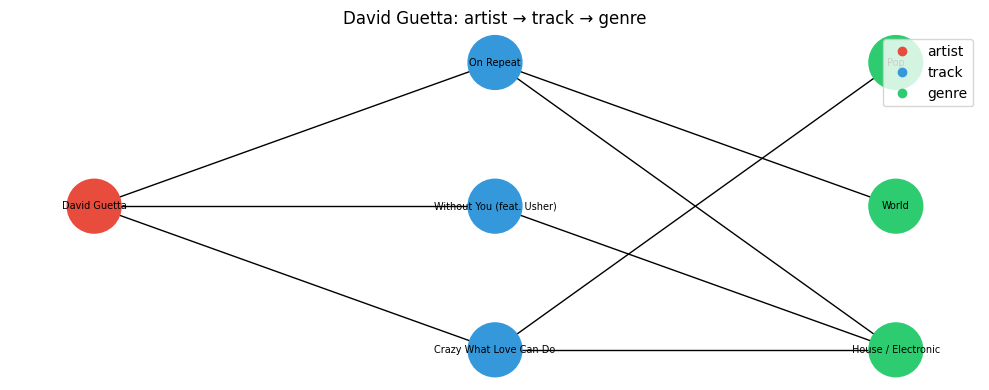

In [38]:
import matplotlib.pyplot as plt

artist = "David Guetta"

if artist not in G_mixed:
    raise ValueError(
        f"{artist} not found in mixed graph. Try another artist in nodes.csv"
    )

tracks = [
    n for n in G_mixed.neighbors(artist) if G_mixed.nodes[n].get("type") == "track"
][:3]
genres = list(
    {
        g
        for t in tracks
        for g in G_mixed.neighbors(t)
        if G_mixed.nodes[g].get("type") == "genre"
    }
)

subgraph = G_mixed.subgraph([artist] + tracks + genres)

color_map = {"artist": "#e74c3c", "track": "#3498db", "genre": "#2ecc71"}
colors = [color_map.get(G_mixed.nodes[n].get("type"), "#95a5a6") for n in subgraph]

# Layout
pos = {artist: (0, 0)}
for i, t in enumerate(tracks):
    pos[t] = (1.5, (i - (len(tracks) - 1) / 2) * 1.2)
for i, g in enumerate(genres):
    pos[g] = (3, (i - (len(genres) - 1) / 2) * 1.2)

fig, ax = plt.subplots(figsize=(10, 4))
nx.draw(
    subgraph,
    pos,
    labels={n: n for n in subgraph},
    node_color=colors,
    node_size=1500,
    font_size=7,
    ax=ax,
)
for label, color in color_map.items():
    ax.plot([], [], "o", color=color, label=label)
ax.legend(loc="upper right")
ax.set_title(f"{artist}: artist → track → genre")
plt.tight_layout()
plt.show()

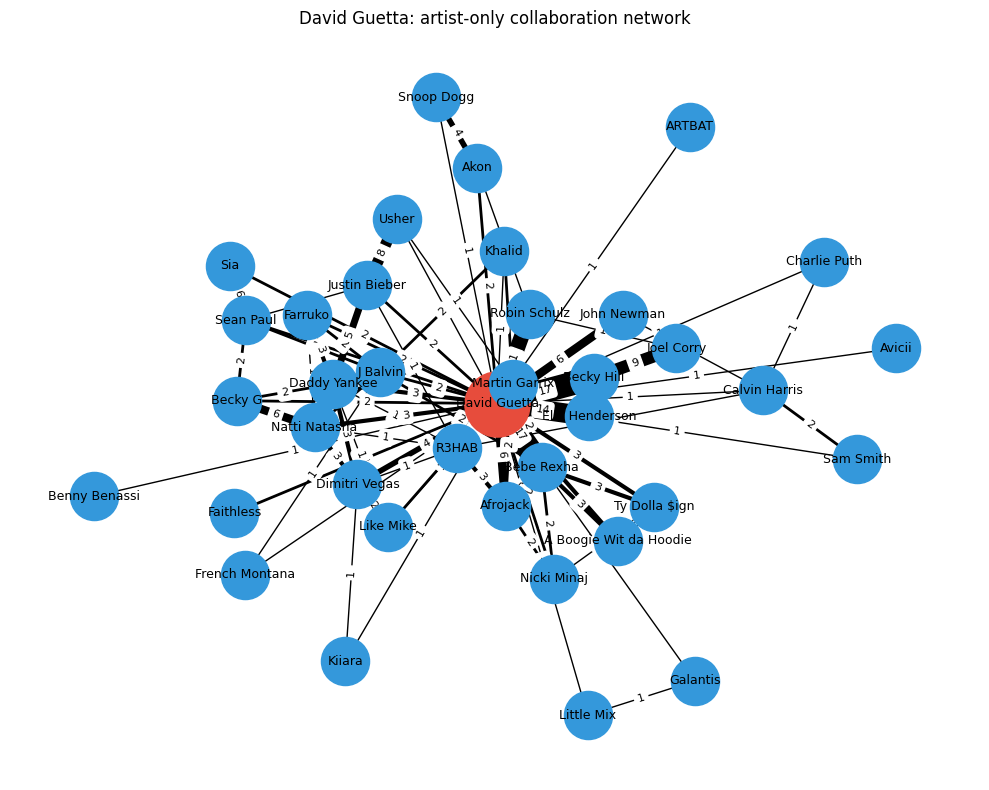

In [39]:
import matplotlib.pyplot as plt
import networkx as nx

artist = "David Guetta"

if artist not in G:
    raise ValueError(f"{artist} not found in artist-only graph.")

# 1-hop collaboration network around the chosen artist
ego = nx.ego_graph(G, artist, radius=1)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(ego, seed=42)

# Draw nodes
center = [artist]
others = [n for n in ego.nodes if n != artist]

nx.draw_networkx_nodes(ego, pos, nodelist=center, node_color="#e74c3c", node_size=2200)

nx.draw_networkx_nodes(ego, pos, nodelist=others, node_color="#3498db", node_size=1200)

# Draw edges
nx.draw_networkx_edges(
    ego, pos, width=[ego[u][v].get("weight", 1) for u, v in ego.edges]
)

# Draw labels
nx.draw_networkx_labels(ego, pos, font_size=9)

# shared-track counts on edges
edge_labels = {(u, v): ego[u][v].get("weight", 1) for u, v in ego.edges}
nx.draw_networkx_edge_labels(ego, pos, edge_labels=edge_labels, font_size=8)

plt.title(f"{artist}: artist-only collaboration network")
plt.axis("off")
plt.tight_layout()
plt.show()

The figure above shows an artist-only collaboration ego network centered on David Guetta. Each node represents an artist, and an edge indicates that two artists appeared on the same track. Edge labels represent the number of shared tracks. Stronger collaborations appear as thicker edges. 

This projected artist network is the structure used for computing degree and eigenvector centrality in our analysis.

In [40]:
largest_cc = max(nx.connected_components(G), key=len)
G_cc = G.subgraph(largest_cc).copy()

print("LCC nodes:", G_cc.number_of_nodes())
print("LCC edges:", G_cc.number_of_edges())

LCC nodes: 701
LCC edges: 2226


Because collaboration networks can contain isolated artists or small disconnected clusters, we restricted our analysis to the largest connected component (LCC) of the graph. This ensures that centrality measures are computed on the main collaboration network.

To ensure stable statistical comparisons, we restricted the analysis to genres represented by at least 10 artists in the largest connected component.

### Q1. Do artists from different genres differ in degree centrality?
- To evaluate whether artists from different genres vary in the number of collaborators they have, we compared degree centrality across genre groups.
    - Degree centrality measures the proportion of other artists in the network that a given artist collaborates with.
- We conducted both a one-way ANOVA and a Kruskal–Wallis test to compare degree centrality distributions across genres.
    - The ANOVA test produced a statistically significant result (F = 7.94, p < 0.001), and the non-parametric Kruskal–Wallis test also showed a significant difference (H = 73.87, p < 0.001).

These results indicate that artists from different genres exhibit significantly different collaboration patterns. Some genres appear to involve more frequent collaboration between artists, leading to higher degree centrality values.


In [41]:
# Degree centrality
deg = nx.degree_centrality(G_cc)

# Eigenvector centrality
eig = nx.eigenvector_centrality(G_cc, max_iter=1000)

cent_df = pd.DataFrame(
    {
        "artist": list(G_cc.nodes()),
        "degree_centrality": [deg[a] for a in G_cc.nodes()],
        "eigenvector_centrality": [eig[a] for a in G_cc.nodes()],
    }
)
cent_df[["artist", "degree_centrality"]].head()

,artist,degree_centrality
0,Neha Kakkar,0.035714
1,Sunidhi Chauhan,0.032857
2,I Prevail,0.002857
3,ILLENIUM,0.064286
4,Nikhita Gandhi,0.012857



### Q2. Do artists from different genres differ in eigenvector centrality?
- We next examined whether genres differ in eigenvector centrality, which measures an artist’s influence within the collaboration network by considering not only the number of collaborators but also how influential those collaborators are.
- Both statistical tests again showed strong evidence of differences across genres.
    - The ANOVA test yielded a highly significant result (F = 44.95, p < 0.001), and the Kruskal–Wallis test confirmed this finding (H = 151.66, p < 0.001).


In [42]:
cent_df[["artist", "eigenvector_centrality"]].head()

,artist,eigenvector_centrality
0,Neha Kakkar,0.227051
1,Sunidhi Chauhan,0.180026
2,I Prevail,0.000232
3,ILLENIUM,0.003750
4,Nikhita Gandhi,0.065113



These results suggest that artists in certain genres tend to occupy more influential positions within the collaboration network, meaning they are more likely to collaborate with other highly connected or influential artists.

In [43]:
analysis_df = cent_df.merge(artist_attrs, on="artist", how="left")

# only rows with genre info
analysis_df = analysis_df.dropna(subset=["primary_genre"])

analysis_df.shape, analysis_df.head()

((701, 7),
             artist  degree_centrality  eigenvector_centrality  \
 0      Neha Kakkar           0.035714                0.227051   
 1  Sunidhi Chauhan           0.032857                0.180026   
 2        I Prevail           0.002857                0.000232   
 3         ILLENIUM           0.064286                0.003750   
 4   Nikhita Gandhi           0.012857                0.065113   
 
         primary_genre  n_tracks  popularity_mean  popularity_max  
 0                 Pop        30        61.425000              77  
 1                 Pop        44        53.018868              67  
 2                Rock        35        61.000000              68  
 3  House / Electronic       132        42.000000              75  
 4                 Pop        14        56.941176              74  )

In [44]:
MIN_PER_GENRE = 10

genre_counts = analysis_df["primary_genre"].value_counts()
valid_genres = genre_counts[genre_counts >= MIN_PER_GENRE].index

analysis_df = analysis_df[analysis_df["primary_genre"].isin(valid_genres)].copy()

print("Genres kept:", len(valid_genres))
print(analysis_df["primary_genre"].value_counts().head(10))

Genres kept: 9
primary_genre
House / Electronic    353
World                 114
Pop                    63
Indie                  53
Rap / Hiphop           50
Rock                   18
R&B                    17
Folk                   12
Alternative            11
Name: count, dtype: int64


In [45]:
GROUP_COL = "primary_genre"

deg_groups = [
    g["degree_centrality"].dropna().values for _, g in analysis_df.groupby(GROUP_COL)
]
eig_groups = [
    g["eigenvector_centrality"].dropna().values
    for _, g in analysis_df.groupby(GROUP_COL)
]

print("Q1 ANOVA degree:", stats.f_oneway(*deg_groups))
print("\nQ1 Kruskal degree:", stats.kruskal(*deg_groups))

print("\nQ2 ANOVA eigen:", stats.f_oneway(*eig_groups))
print("\nQ2 Kruskal eigen:", stats.kruskal(*eig_groups))

Q1 ANOVA degree: F_onewayResult(statistic=np.float64(7.9405435923448), pvalue=np.float64(2.9623957848518776e-10))

Q1 Kruskal degree: KruskalResult(statistic=np.float64(73.86767561802097), pvalue=np.float64(8.311654900502743e-13))

Q2 ANOVA eigen: F_onewayResult(statistic=np.float64(44.94746461611855), pvalue=np.float64(5.452616657754461e-58))

Q2 Kruskal eigen: KruskalResult(statistic=np.float64(151.66057657347233), pvalue=np.float64(8.83065568373144e-29))


#### Q3. Are differences in degree and eigenvector centrality across musical genres statistically significant?
- To evaluate the magnitude of genre differences in centrality measures, we computed η² (eta squared) effect sizes based on the ANOVA models.
    - Eta squared measures the proportion of total variance in a variable that can be explained by group membership (in this case, musical genre).
- For degree centrality, the estimated effect size was η² = 0.085, indicating a moderate effect.
    - This suggests that genre explains approximately 8.5% of the variation in the number of collaborators an artist has.
    - While genre does influence collaboration patterns, a substantial portion of variation is likely explained by other factors such as artist popularity, career stage, or industry connections.
- For eigenvector centrality, the effect size was substantially larger at η² = 0.345, representing a large effect.
    - This indicates that genre explains roughly 34.5% of the variation in network influence, meaning that artists in certain genres are significantly more likely to occupy influential positions within the collaboration network.

Overall, these results suggest that genre plays a stronger role in determining an artist’s influence within the collaboration network than it does in determining the sheer number of collaborators.

In [46]:
def eta_squared(df: pd.DataFrame, y: str, group: str) -> float:
    model = smf.ols(f"{y} ~ C({group})", data=df).fit()
    aov = sm.stats.anova_lm(model, typ=2)
    ss_between = aov.loc[f"C({group})", "sum_sq"]
    ss_total = ss_between + aov.loc["Residual", "sum_sq"]
    return float(ss_between / ss_total)


print("Eta^2 degree:", eta_squared(analysis_df, "degree_centrality", GROUP_COL))
print(
    "\nEta^2 eigenvector:",
    eta_squared(analysis_df, "eigenvector_centrality", GROUP_COL),
)

Eta^2 degree: 0.08520761105418741

Eta^2 eigenvector: 0.34522534481484823


### Q4. Do certain genres have more extreme high-centrality artists than others?
- To examine whether some genres contain more extreme high-centrality artists than others, we summarized the upper tails of the centrality distributions using the 95th percentile (p95) and maximum values for both degree and eigenvector centrality.
    - We also calculated a tailiness ratio using the 99th percentile divided by the median (p99/p50) of eigenvector centrality within each genre.
- The results show clear differences across genres.
    - For degree centrality, genres such as World, House/Electronic, Pop, and Rap/Hip-Hop include artists with especially high numbers of collaborators.
    - For eigenvector centrality, Pop and World exhibit the largest extreme values, indicating that these genres include some of the most influential artists in the collaboration network.
- The tailiness analysis provides additional insight into how concentrated these extremes are.
    - Indie, World, and Rap/Hip-Hop show the largest p99/p50 ratios, suggesting that influence in these genres is highly concentrated in a small number of standout artists.
    - In contrast, Pop has a relatively lower tail ratio despite its high maximum eigenvector centrality, indicating that influence in Pop is distributed more broadly rather than being dominated by only one or two extreme hubs.

Overall, these results suggest that genres differ not only in their average levels of collaboration and influence, but also in how strongly influence is concentrated among a small subset of artists. 

However, these tail-based comparisons should be interpreted cautiously for smaller genre groups, since percentile estimates can be more sensitive to a limited number of observations.

In [47]:
extremes = (
    analysis_df.groupby(GROUP_COL)
    .agg(
        n=("artist", "count"),
        deg_p95=("degree_centrality", lambda x: np.nanpercentile(x, 95)),
        deg_max=("degree_centrality", "max"),
        eig_p95=("eigenvector_centrality", lambda x: np.nanpercentile(x, 95)),
        eig_max=("eigenvector_centrality", "max"),
    )
    .sort_values("eig_p95", ascending=False)
)

print("Extremes by genre (p95 and max)")
print(extremes)

tailiness = analysis_df.groupby(GROUP_COL, as_index=True).agg(
    eig_p99=("eigenvector_centrality", lambda x: np.nanpercentile(x, 99)),
    eig_p50=("eigenvector_centrality", lambda x: np.nanpercentile(x, 50)),
)
tailiness["eig_tail_ratio_p99_p50"] = tailiness["eig_p99"] / tailiness["eig_p50"].clip(
    lower=1e-12
)
tailiness = tailiness.sort_values("eig_tail_ratio_p99_p50", ascending=False)

print("\nQ4b) Tailiness (p99/p50) by genre")
print(tailiness)

Extremes by genre (p95 and max)
                      n   deg_p95   deg_max   eig_p95   eig_max
primary_genre                                                  
Pop                  63  0.035714  0.055714  0.223296  0.296580
Folk                 12  0.018500  0.027143  0.096309  0.133171
Indie                53  0.014857  0.028571  0.063069  0.114612
Rap / Hiphop         50  0.034071  0.047143  0.033671  0.194122
World               114  0.029071  0.080000  0.031125  0.285659
House / Electronic  353  0.021429  0.064286  0.004686  0.034208
R&B                  17  0.012286  0.015714  0.002059  0.004261
Alternative          11  0.012143  0.014286  0.001204  0.001376
Rock                 18  0.007571  0.010000  0.000882  0.001599

Q4b) Tailiness (p99/p50) by genre
                     eig_p99   eig_p50  eig_tail_ratio_p99_p50
primary_genre                                                 
Indie               0.111593  0.000714              156.272096
World               0.145902  0.001316  

### Q5. Does the relationship between centrality and popularity differ by genre?
- To examine whether the relationship between network influence and popularity varies across genres, we estimated a linear regression model predicting average track popularity from eigenvector centrality, genre, and their interaction.
    - Eigenvector centrality was scaled to improve numerical stability.
- The overall regression model was statistically significant (F = 8.94, p < 0.001) and explained approximately 18% of the variance in artist popularity (R² = 0.184).
- However, the main effect of eigenvector centrality was not statistically significant (p = 0.326), indicating that more influential positions in the collaboration network do not necessarily correspond to higher average popularity.
- In addition, none of the interaction terms between centrality and genre were statistically significant. This suggests that the relationship between network influence and popularity does not vary substantially across musical genres.

Overall, while genre strongly influences collaboration patterns and network centrality (as shown in earlier analyses), these differences in network position do not appear to translate into systematic differences in artist popularity across genres.

In [48]:
analysis_df["eig_scaled"] = analysis_df["eigenvector_centrality"] * 1e6

reg_df = analysis_df.dropna(subset=["popularity_mean", "eig_scaled", GROUP_COL]).copy()

model = smf.ols(f"popularity_mean ~ eig_scaled * C({GROUP_COL})", data=reg_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        popularity_mean   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     8.940
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           4.21e-21
Time:                        15:42:26   Log-Likelihood:                -2956.9
No. Observations:                 691   AIC:                             5950.
Df Residuals:                     673   BIC:                             6031.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [49]:
analysis_df.head()

,artist,degree_centrality,eigenvector_centrality,primary_genre,n_tracks,popularity_mean,popularity_max,eig_scaled
0,Neha Kakkar,0.035714,0.227051,Pop,30,61.425000,77,227050.602156
1,Sunidhi Chauhan,0.032857,0.180026,Pop,44,53.018868,67,180026.306632
2,I Prevail,0.002857,0.000232,Rock,35,61.000000,68,231.999751
3,ILLENIUM,0.064286,0.003750,House / Electronic,132,42.000000,75,3750.345378
4,Nikhita Gandhi,0.012857,0.065113,Pop,14,56.941176,74,65113.191710


## Conclusion

This analysis examined how collaboration patterns differ across musical genres and whether an artist’s structural position in the collaboration network is associated with popularity outcomes. We first evaluated whether artists from different genres occupy different positions in the network by comparing degree centrality (number of collaborators) and eigenvector centrality (influence within the collaboration network). The results show statistically significant differences across genres, indicating that collaboration structures vary meaningfully between musical communities. In particular, genres such as House/Electronic, World, and Rap/Hip-Hop tend to include artists with higher levels of connectivity and influence within the collaboration network.

Further analysis of the upper tails of the centrality distributions showed that some genres contain more extreme high-centrality artists than others. Genres such as Indie, World, and Rap/Hip-Hop display highly skewed distributions where a small number of artists occupy very influential positions in the collaboration network, while genres like Pop exhibit high centrality values that are more broadly distributed among artists.

Finally, we tested our predictive hypothesis that artists with higher degree and eigenvector centrality would also exhibit higher Spotify popularity scores, under the assumption that greater collaboration and network influence could expand audience reach. However, the regression analysis found no statistically significant relationship between centrality and average artist popularity, and the strength of this relationship did not differ significantly across genres.

Overall, these findings suggest that while collaboration networks differ substantially across musical genres and produce distinct structural patterns of influence, occupying a more central position in the collaboration network does not necessarily translate into higher popularity on Spotify. Popularity likely depends on additional factors beyond network position, such as marketing, fan base dynamics, platform algorithms, and genre-specific audience behavior.